In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#file read
df = pd.read_csv("usecar_prediction.csv") 
df

,Year,KM_Driven,Fuel_Type,Owner_Count,Mileage,Price
0,2019,92851,CNG,1,12.513284,630357.316657
1,2019,136232,CNG,2,23.770667,323644.905606
2,2014,139955,CNG,3,23.557733,345867.295416
3,2021,68250,Petrol,3,14.322857,351401.757154
4,2009,147969,Petrol,1,17.042746,592998.777029
...,...,...,...,...,...,...
95,2021,38232,CNG,2,12.084755,506389.031714
96,2009,89142,Petrol,1,22.997417,758761.325066
97,2012,10981,Petrol,3,16.712255,442078.086296
98,2021,29808,Petrol,1,17.164726,339207.583501


In [13]:
print(df.head())

   Year  KM_Driven Fuel_Type  Owner_Count    Mileage          Price
0  2019      92851       CNG            1  12.513284  630357.316657
1  2019     136232       CNG            2  23.770667  323644.905606
2  2014     139955       CNG            3  23.557733  345867.295416
3  2021      68250    Petrol            3  14.322857  351401.757154
4  2009     147969    Petrol            1  17.042746  592998.777029


In [14]:
#for explor dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         100 non-null    int64  
 1   KM_Driven    100 non-null    int64  
 2   Fuel_Type    100 non-null    object 
 3   Owner_Count  100 non-null    int64  
 4   Mileage      100 non-null    float64
 5   Price        100 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 4.8+ KB
None


In [21]:
df.isnull().sum()

Year           0
KM_Driven      0
Fuel_Type      0
Owner_Count    0
Mileage        0
Price          0
dtype: int64

In [15]:
#check null value
print("Missing values:\n", df.isnull().sum())

Missing values:
 Year           0
KM_Driven      0
Fuel_Type      0
Owner_Count    0
Mileage        0
Price          0
dtype: int64


In [20]:
df.describe()

,Year,KM_Driven,Owner_Count,Mileage,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000
mean,2015.080000,75922.89000,1.970000,18.680664,589599.649449
std,4.560879,42971.76541,0.846323,3.868377,202310.163958
min,2008.000000,5503.00000,1.000000,12.063215,226070.774913
25%,2011.000000,36544.25000,1.000000,15.434399,408386.346869
50%,2014.000000,75779.50000,2.000000,18.234341,615083.776923
75%,2019.000000,110431.75000,3.000000,22.671269,770935.109288
max,2023.000000,148942.00000,3.000000,24.984275,879245.226542


In [16]:
# Option 1: Drop null rows
df_clean = df.dropna()

In [22]:
# Categorize  data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])

df.head()

,Year,KM_Driven,Fuel_Type,Owner_Count,Mileage,Price
0,2019,92851,0,1,12.513284,630357.316657
1,2019,136232,0,2,23.770667,323644.905606
2,2014,139955,0,3,23.557733,345867.295416
3,2021,68250,2,3,14.322857,351401.757154
4,2009,147969,2,1,17.042746,592998.777029


In [23]:
#  check Featurs 

X = df.drop("Price", axis=1)
y = df["Price"]

In [24]:
# for Model train test 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# model learning(Linear regression)

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
#prediction 

y_pred = model.predict(X_test)

print(y_pred)

[590008.28414608 579409.63087936 575838.93694509 603264.21954407
 588124.66609566 599859.64668611 571902.97555556 536278.46541145
 540893.95005089 534026.83109999 550004.0726376  556303.23937736
 565883.71590503 588840.76757358 571757.59016319 604912.83695486
 589658.4858929  613104.00508694 582773.40866949 587405.06678811]


In [27]:
# model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 184947.31862225663
MSE: 40584397306.22707
R2 Score: -0.18064998700555246


In [28]:
#Compare prediction 

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head())

     Actual Price  Predicted Price
83  439528.159401    590008.284146
53  770876.785772    579409.630879
70  879245.226542    575838.936945
45  828132.122120    603264.219544
44  851948.850546    588124.666096


In [18]:
#outliers find
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Price'] < Q1 - 1.5*IQR) | (df['Price'] > Q3 + 1.5*IQR)]
print("Outliers in Price:\n", outliers)


Outliers in Price:
 Empty DataFrame
Columns: [Year, KM_Driven, Fuel_Type, Owner_Count, Mileage, Price]
Index: []


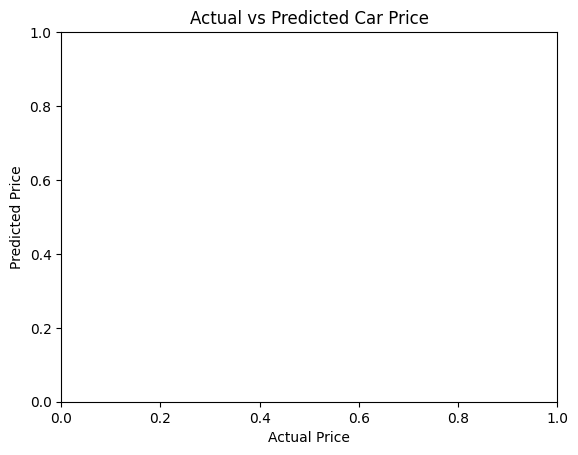

In [29]:
# plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

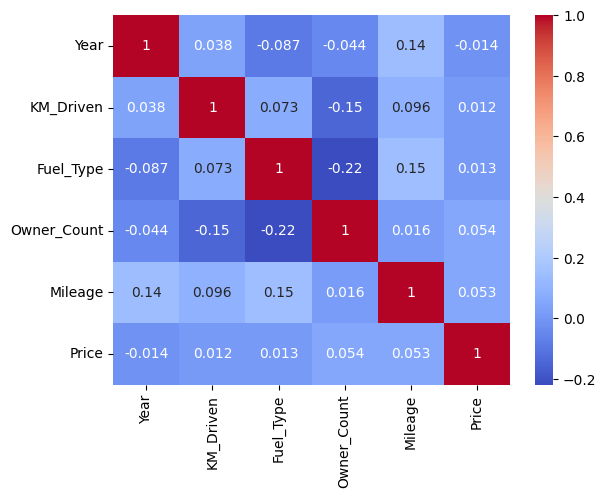

In [31]:
# Correlation heatmap
#plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

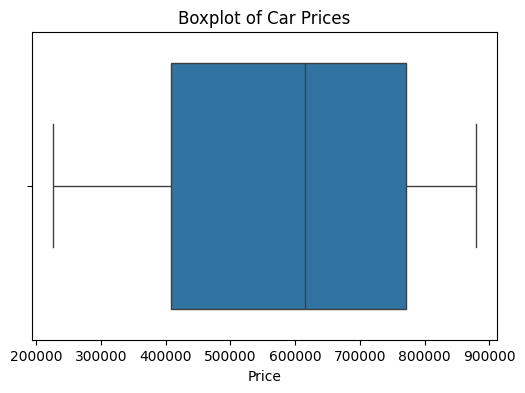

In [30]:
#Boxplot prize
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Car Prices")
plt.show()
